In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.shape)
print(df.head())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

In [2]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.dtypes)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
0
mean radius                float64
mean texture               float64
mean perimeter  

In [3]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [4]:
print(data.target_names)

['malignant' 'benign']


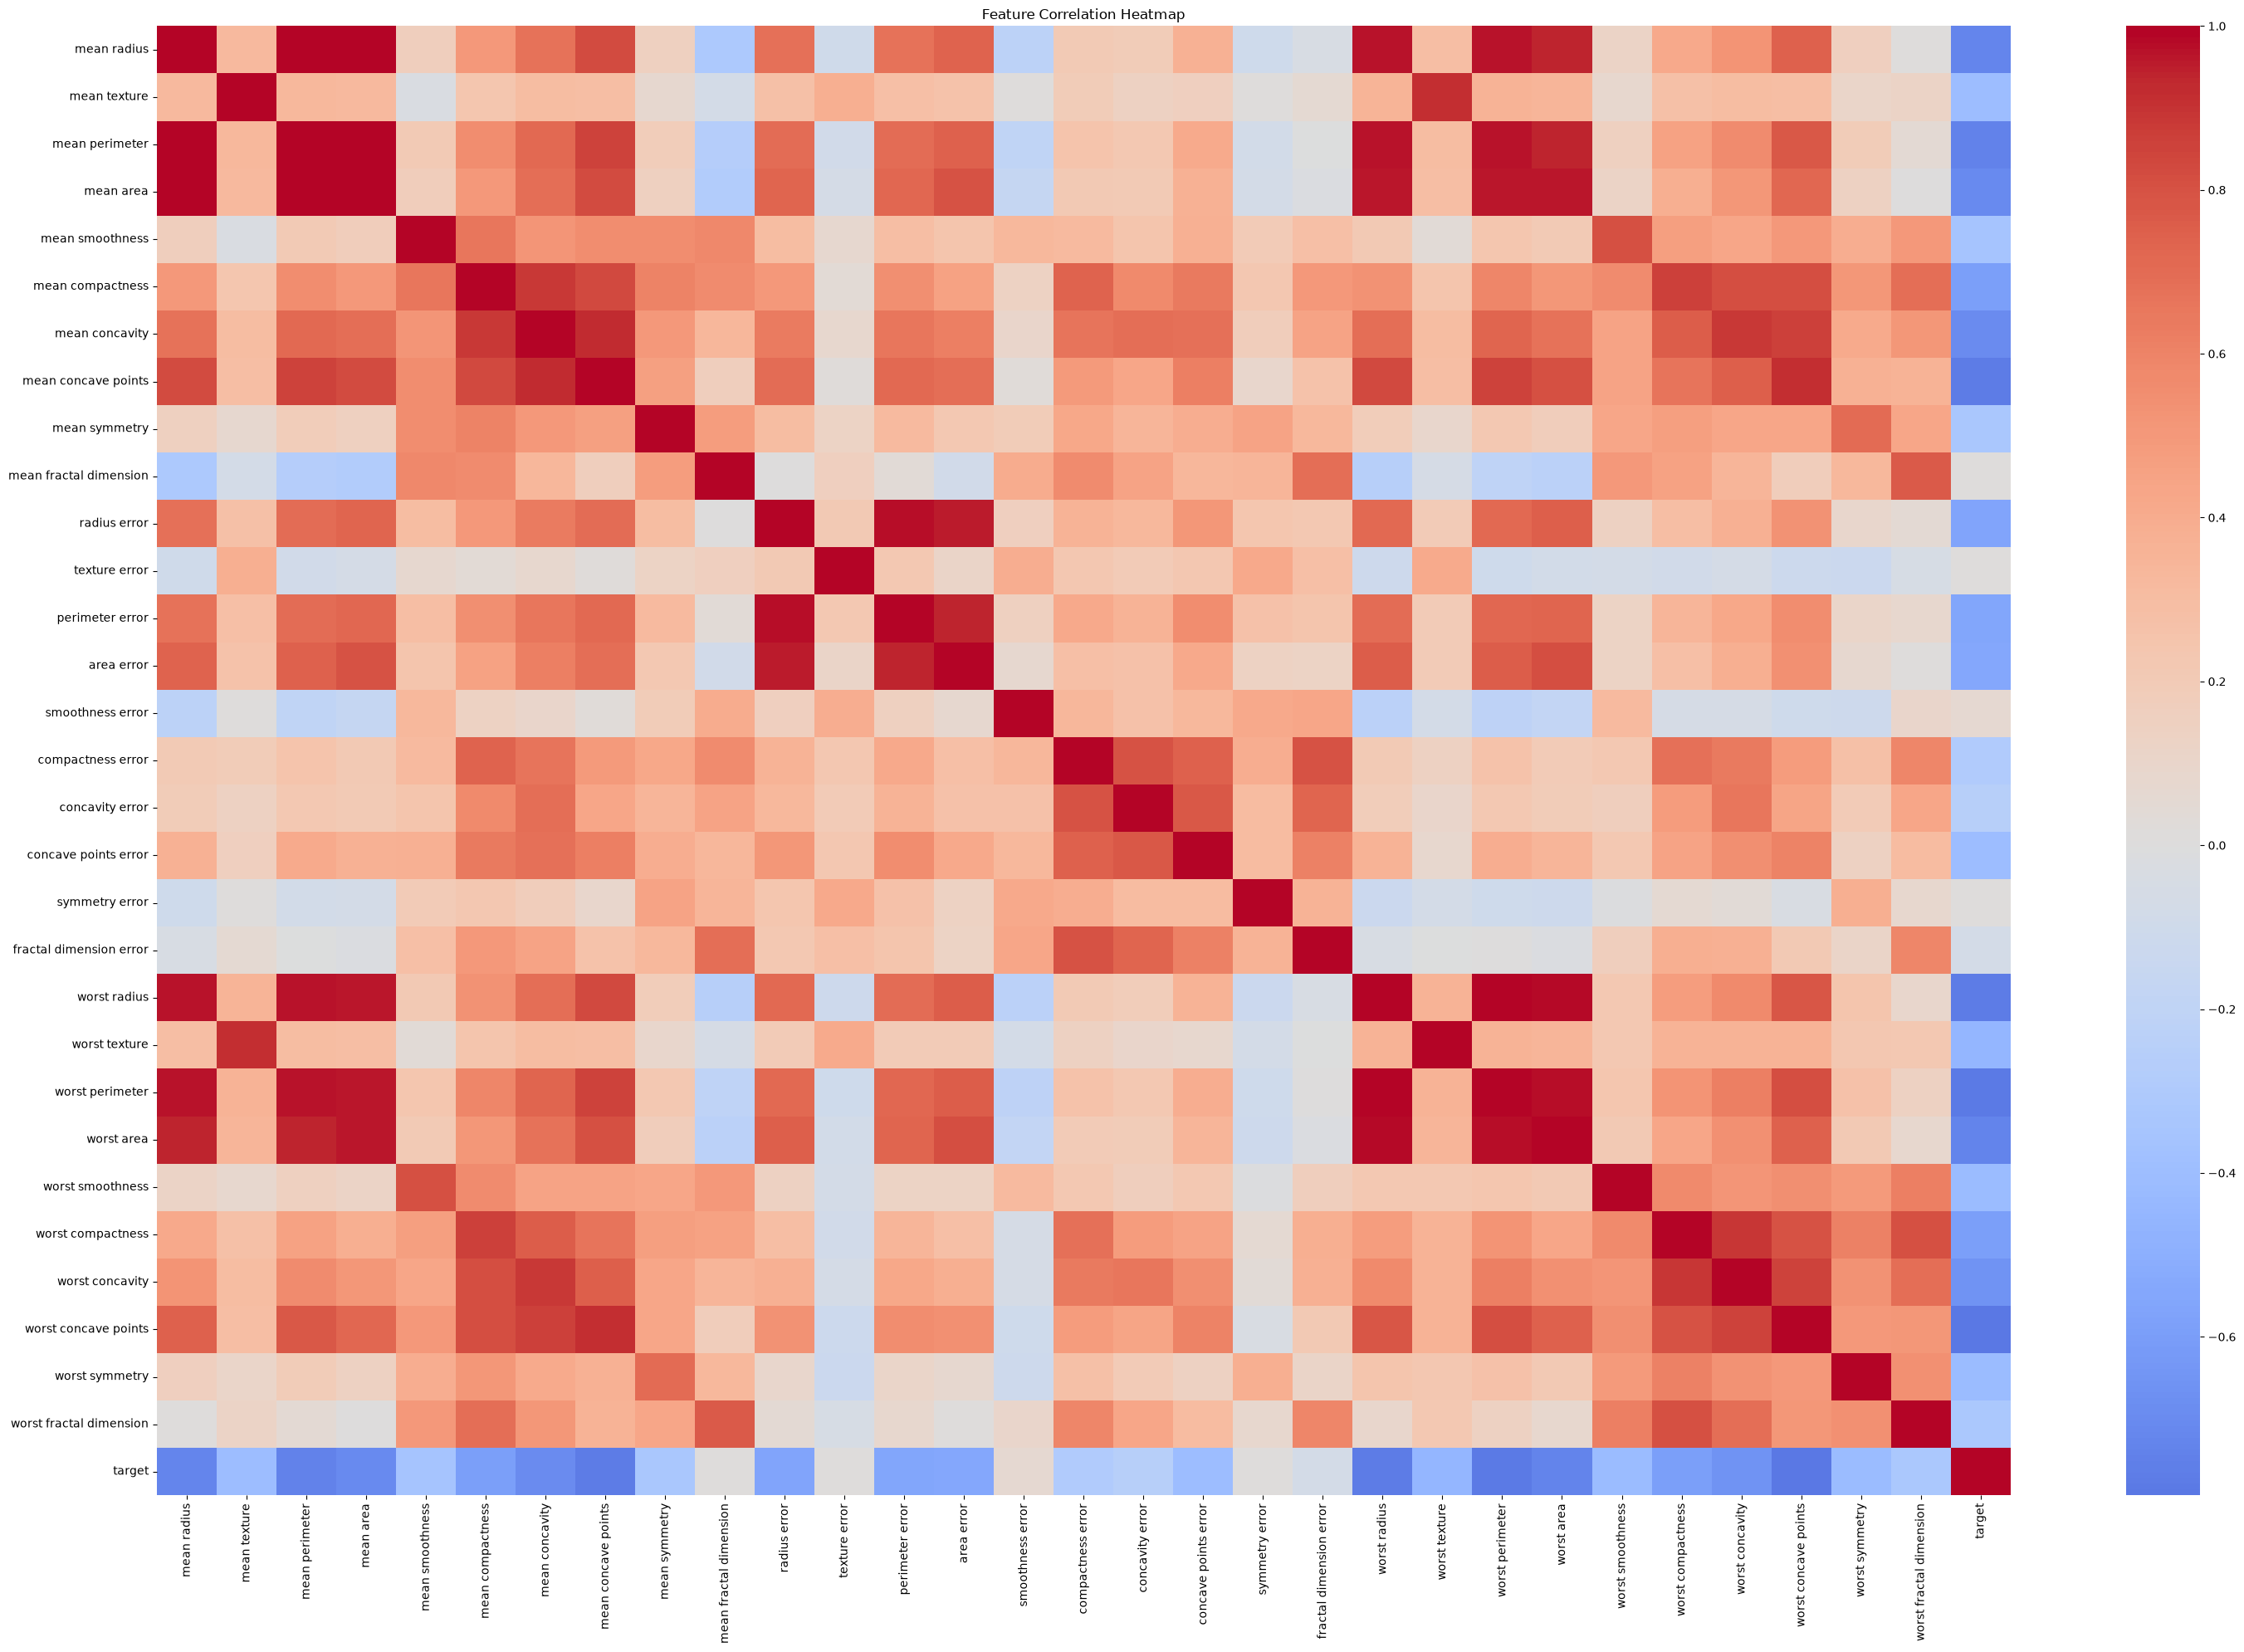

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

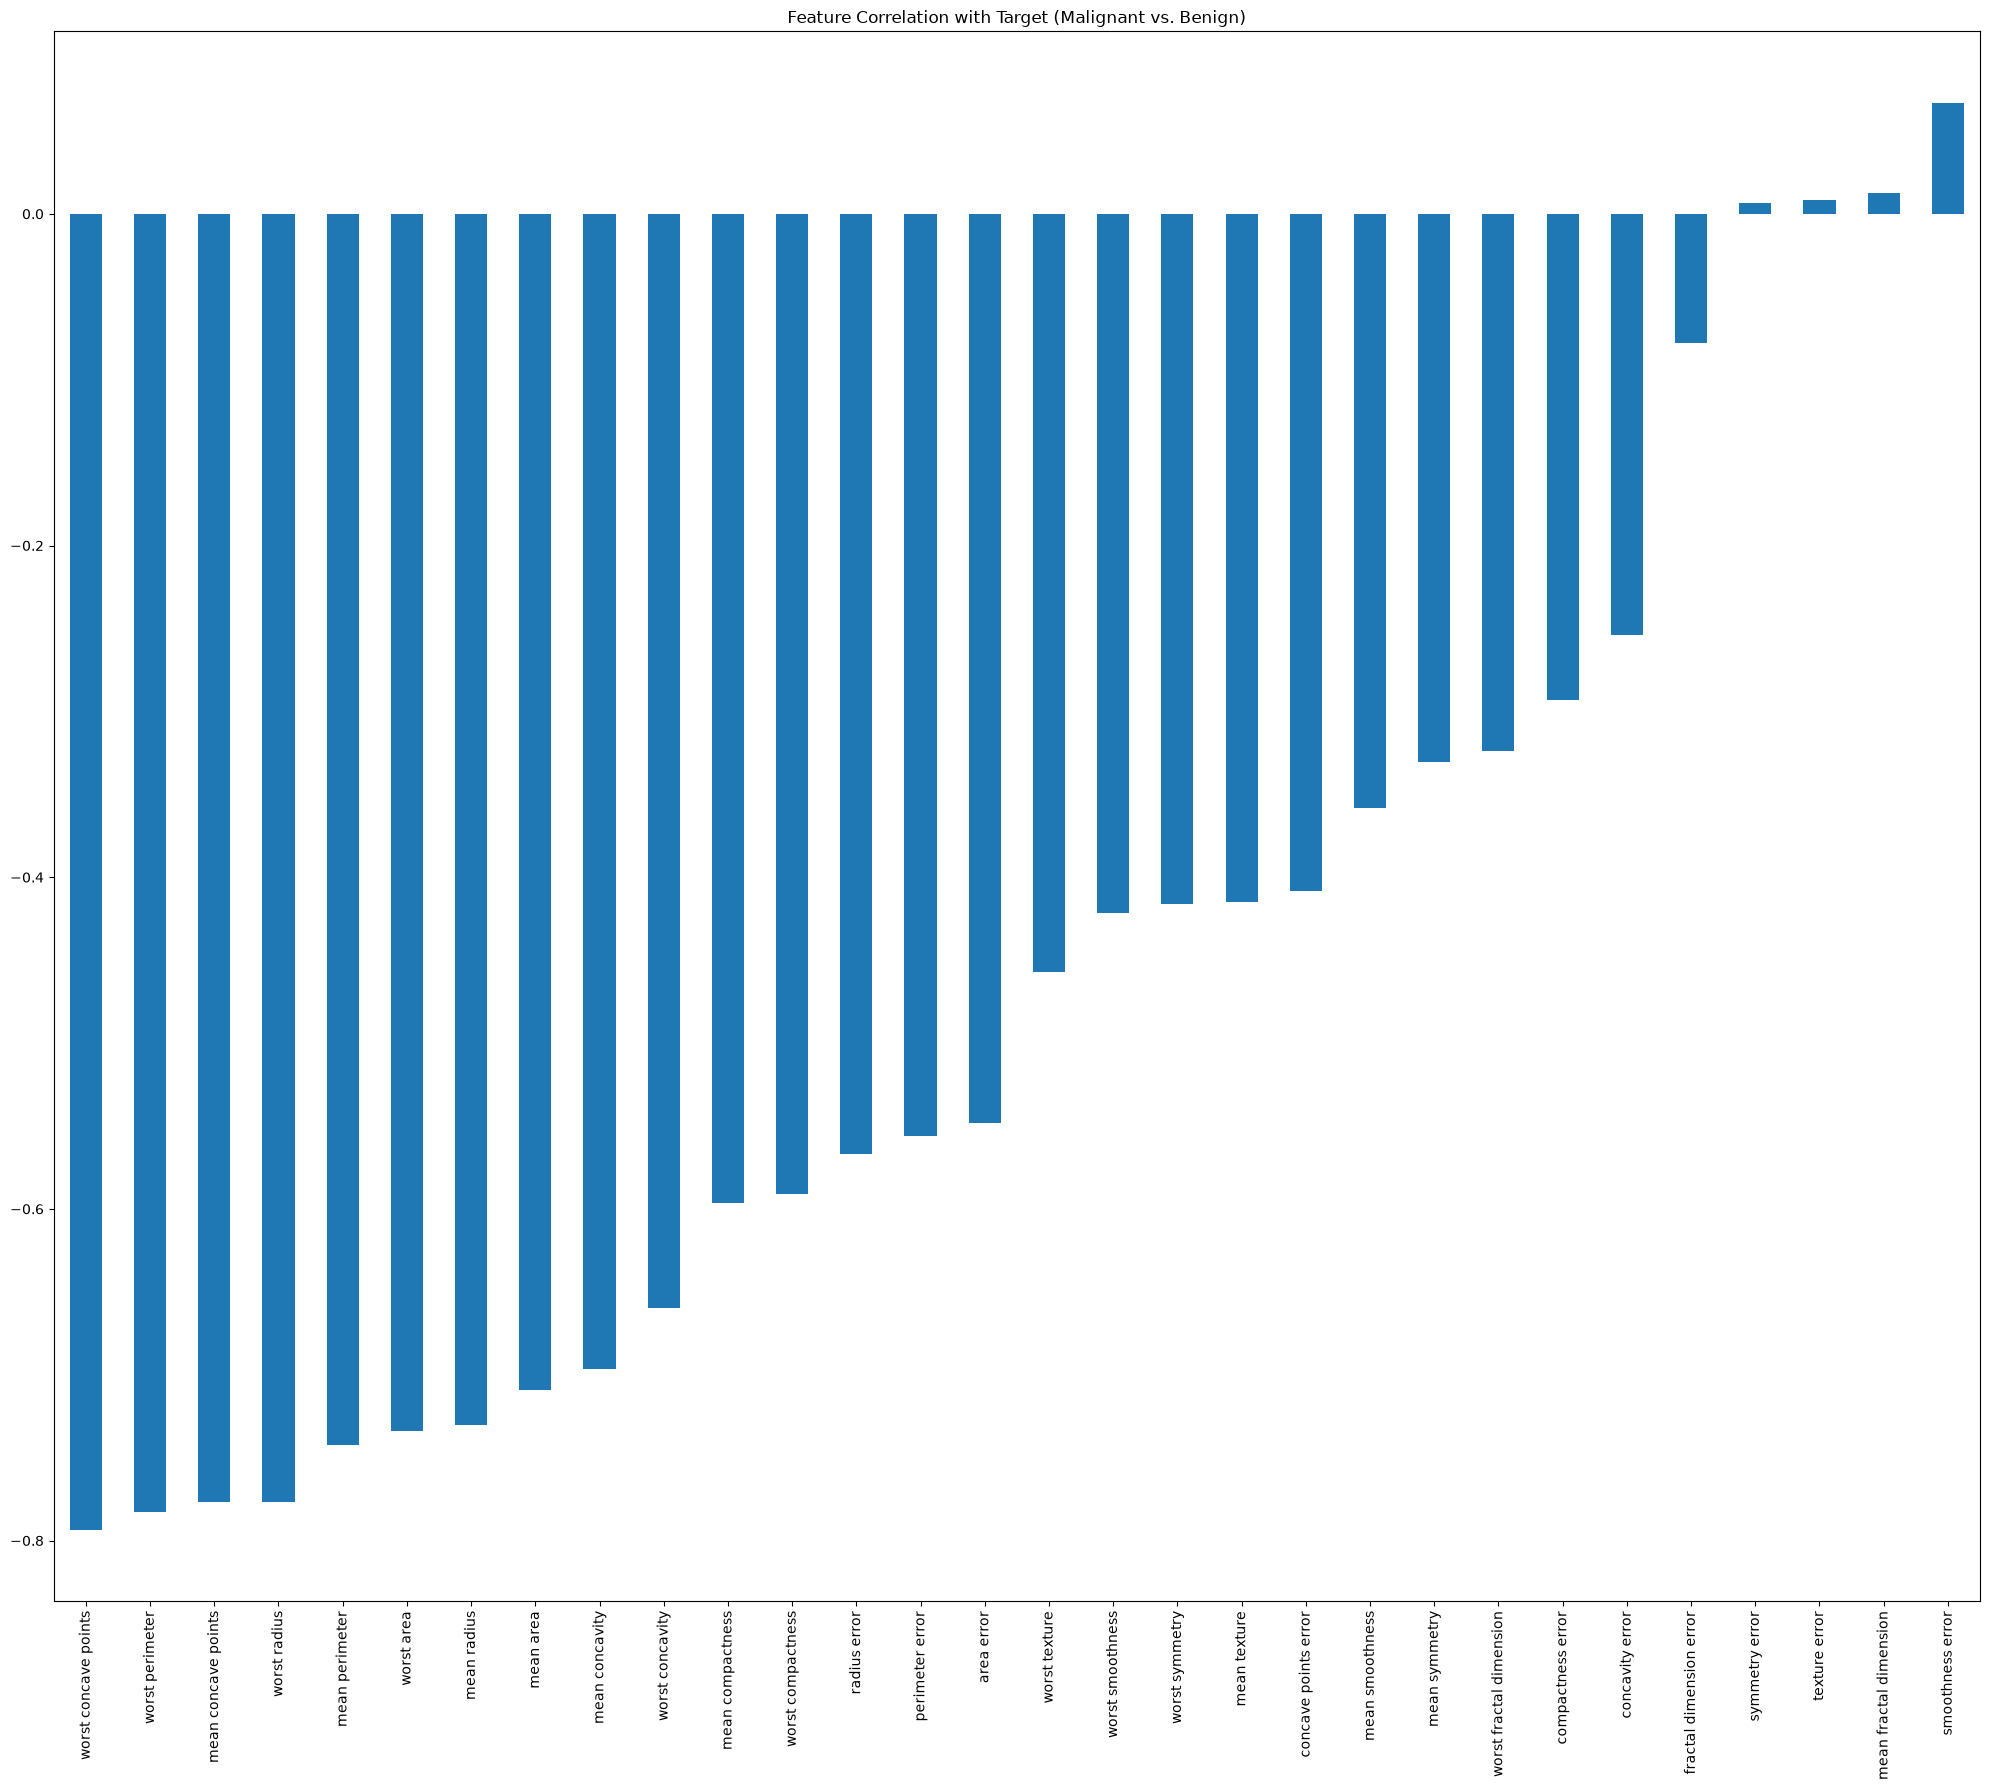

In [8]:
plt.figure(figsize=(20,18))
correlation_with_target = df.corr()["target"].sort_values()
correlation_with_target.drop('target').plot(kind='bar')
plt.title("Feature Correlation with Target (Malignant vs. Benign)")
plt.tight_layout()
plt.show()

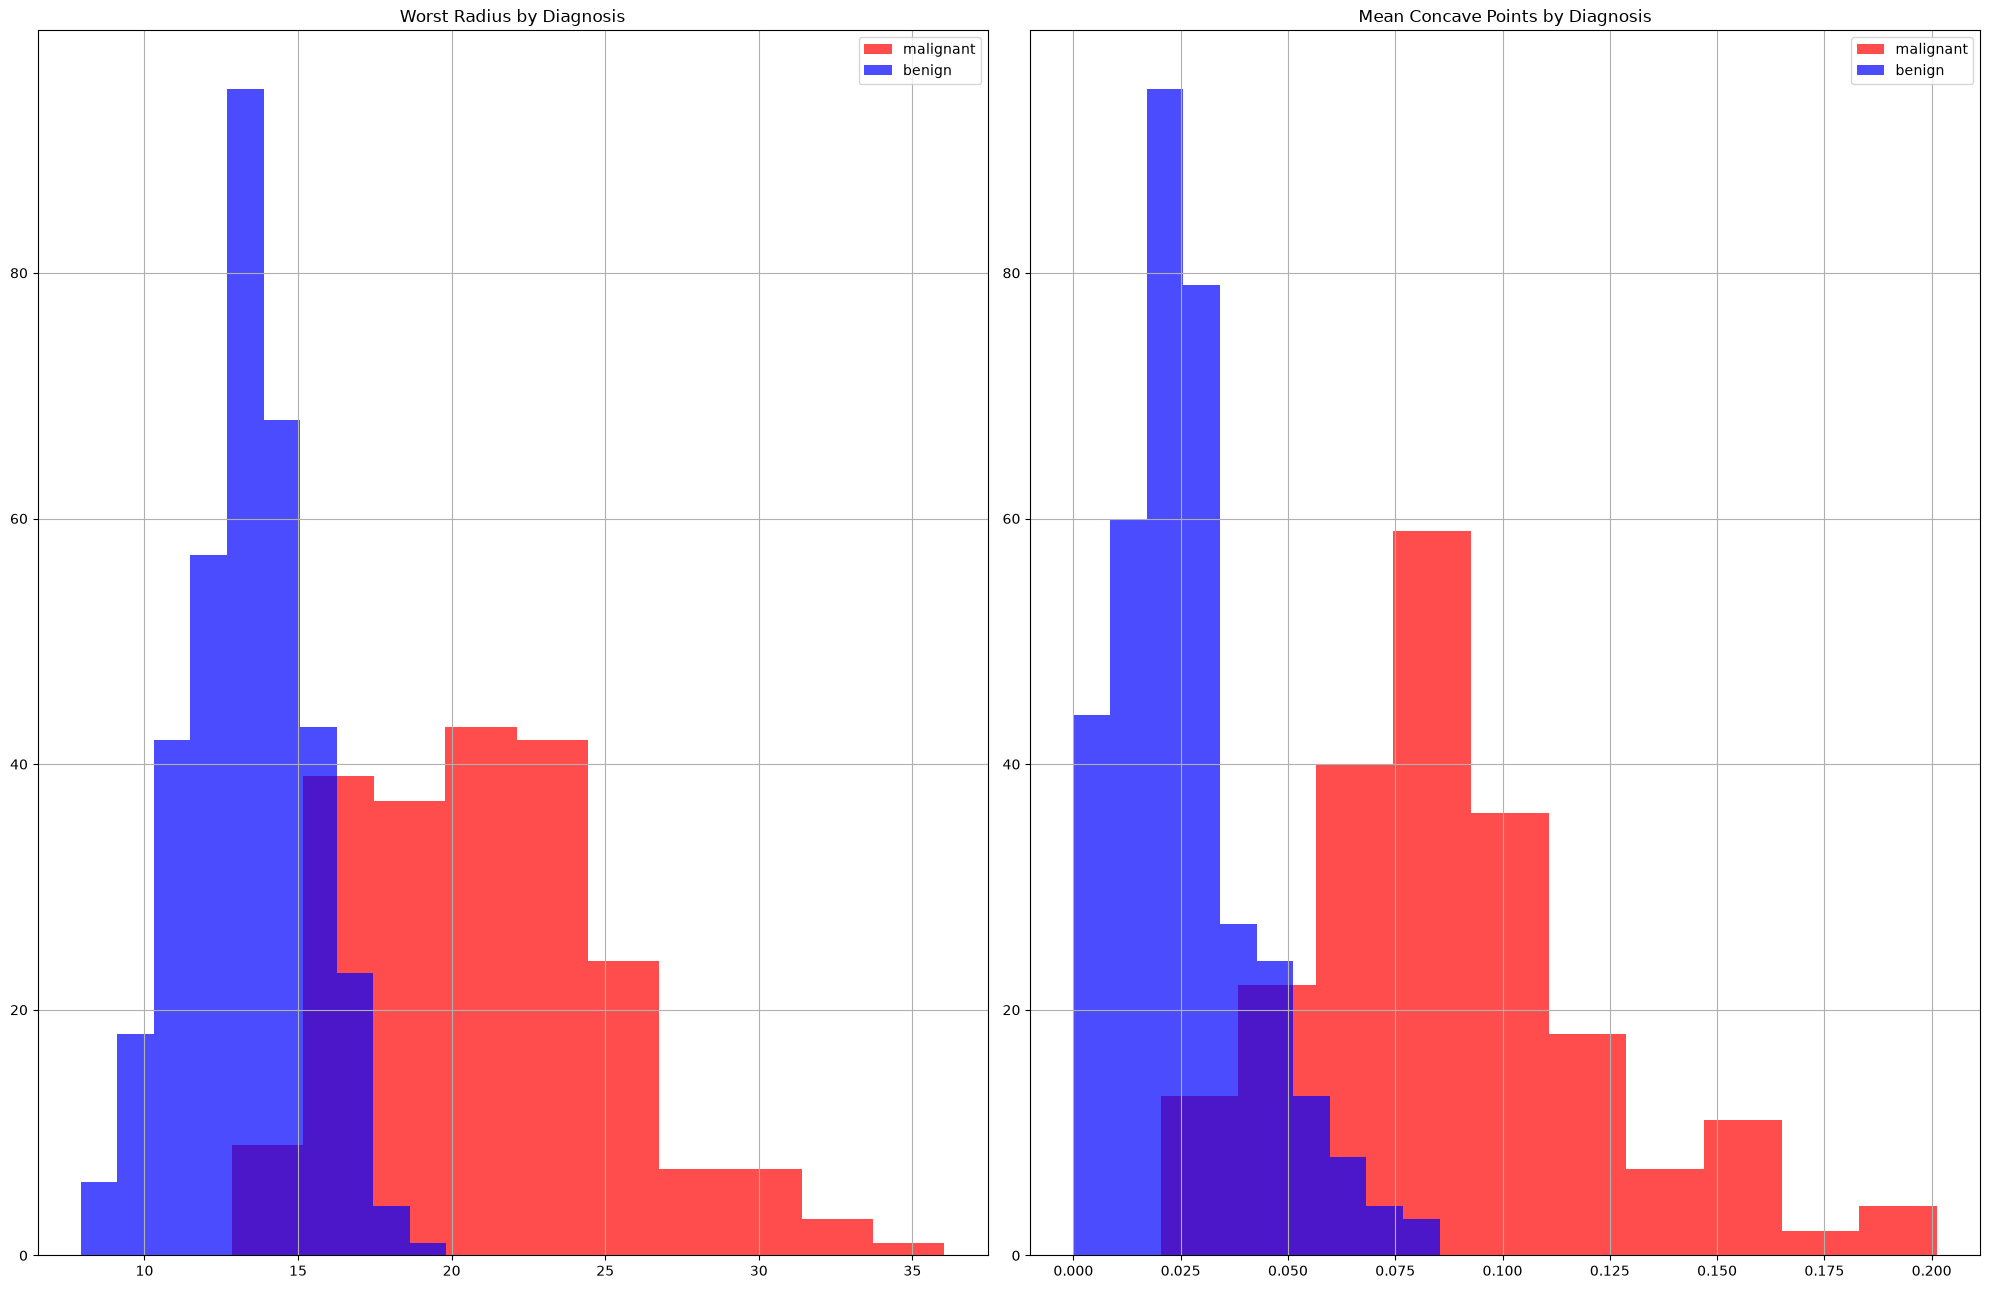

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 13))
df[df['target'] ==0]['worst radius'].hist(ax=axes[0], alpha=0.7, color ='red', label= 'malignant')
df[df['target'] ==1]['worst radius'].hist(ax=axes[0], alpha=0.7, color = 'blue', label= 'benign')
axes[0].set_title('Worst Radius by Diagnosis')
axes[0].legend()

df[df['target'] ==0]['mean concave points'].hist(ax=axes[1], alpha=0.7, color ='red', label= 'malignant')
df[df['target'] ==1]['mean concave points'].hist(ax=axes[1], alpha=0.7, color = 'blue', label= 'benign')
axes[1].set_title('Mean Concave Points by Diagnosis')
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\meera\AppData\Local\Temp\ipykernel_31400\1423678616.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['red','blue'])


<function matplotlib.pyplot.show(close=None, block=None)>

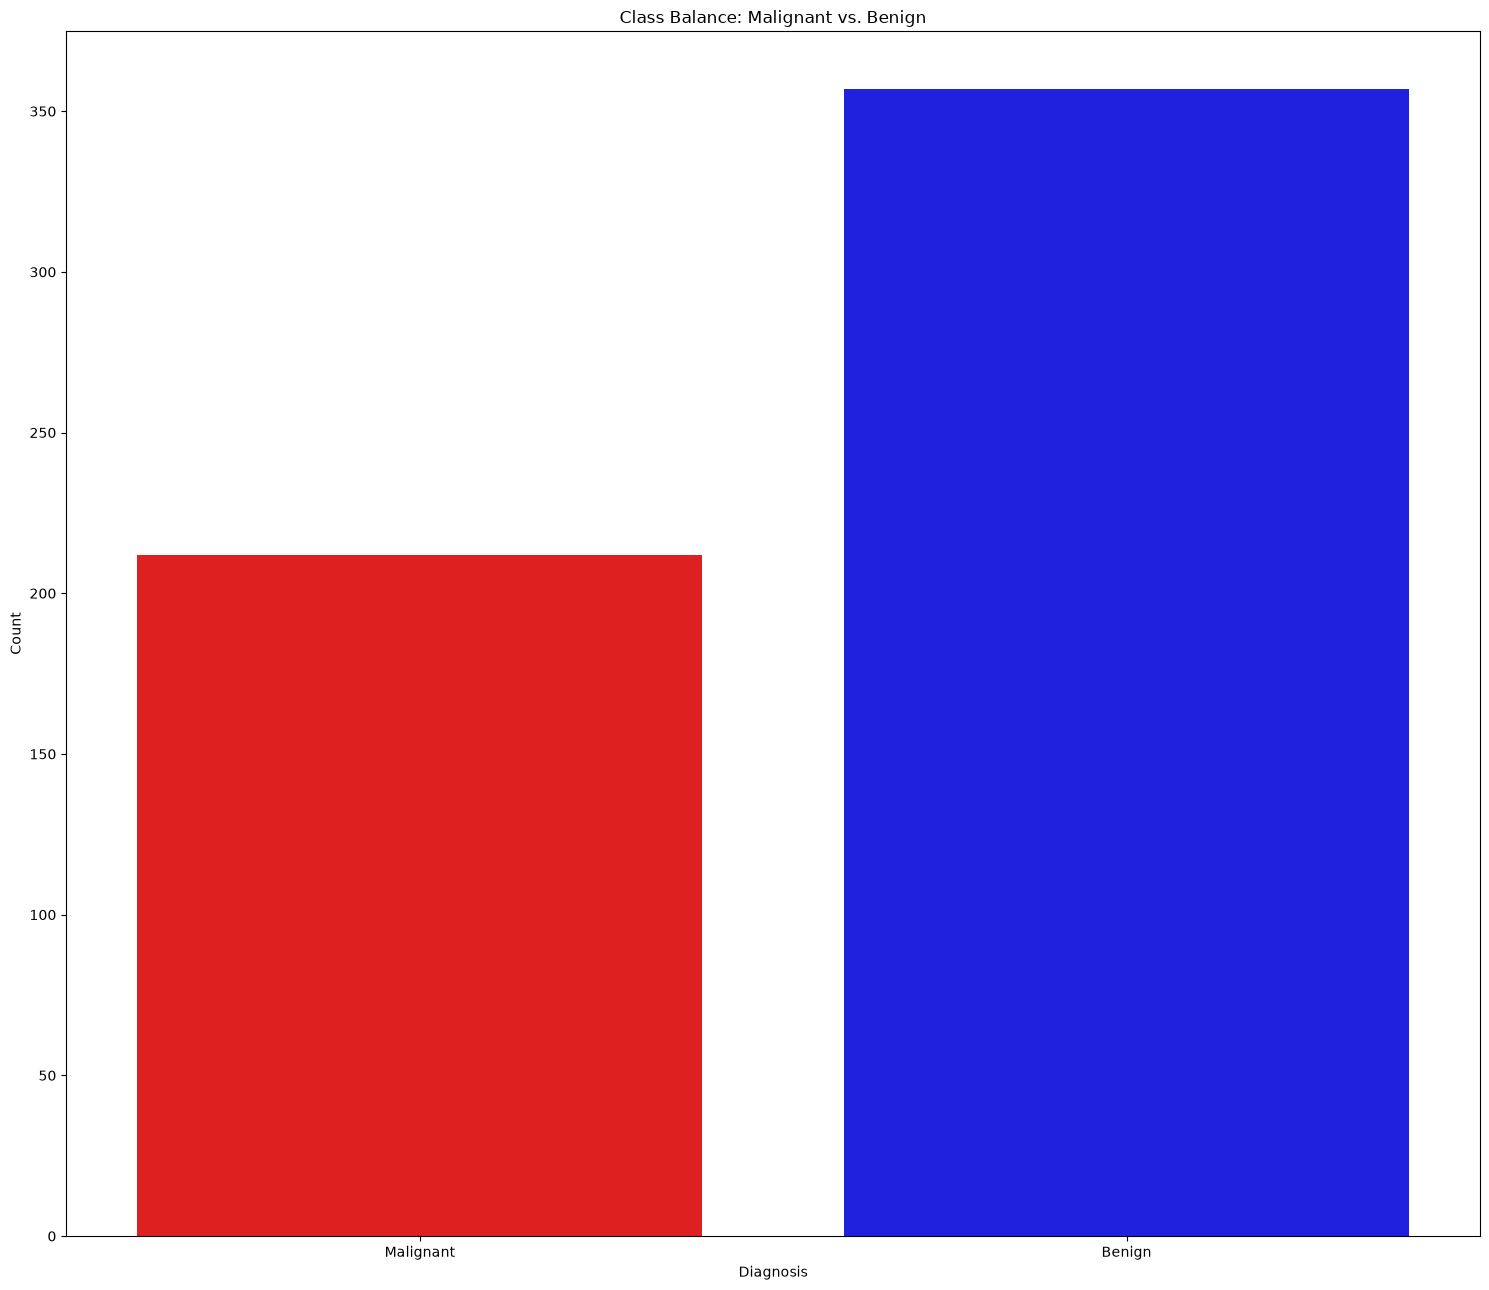

In [15]:
plt.figure(figsize=(15,13))
sns.countplot(x='target', data=df, palette=['red','blue'])
plt.xticks([0,1], ['Malignant', 'Benign'])
plt.title('Class Balance: Malignant vs. Benign')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show

C:\Users\meera\AppData\Local\Temp\ipykernel_31400\1670657610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='worst radius', data= df, palette=['red', 'blue'], ax=axes[0])
C:\Users\meera\AppData\Local\Temp\ipykernel_31400\1670657610.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Malignant', 'Benign'])
C:\Users\meera\AppData\Local\Temp\ipykernel_31400\1670657610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='mean concave points', data= df, palette=['red', 'blue'], ax=axes[1])
C:\Users\meera\AppData\Local\

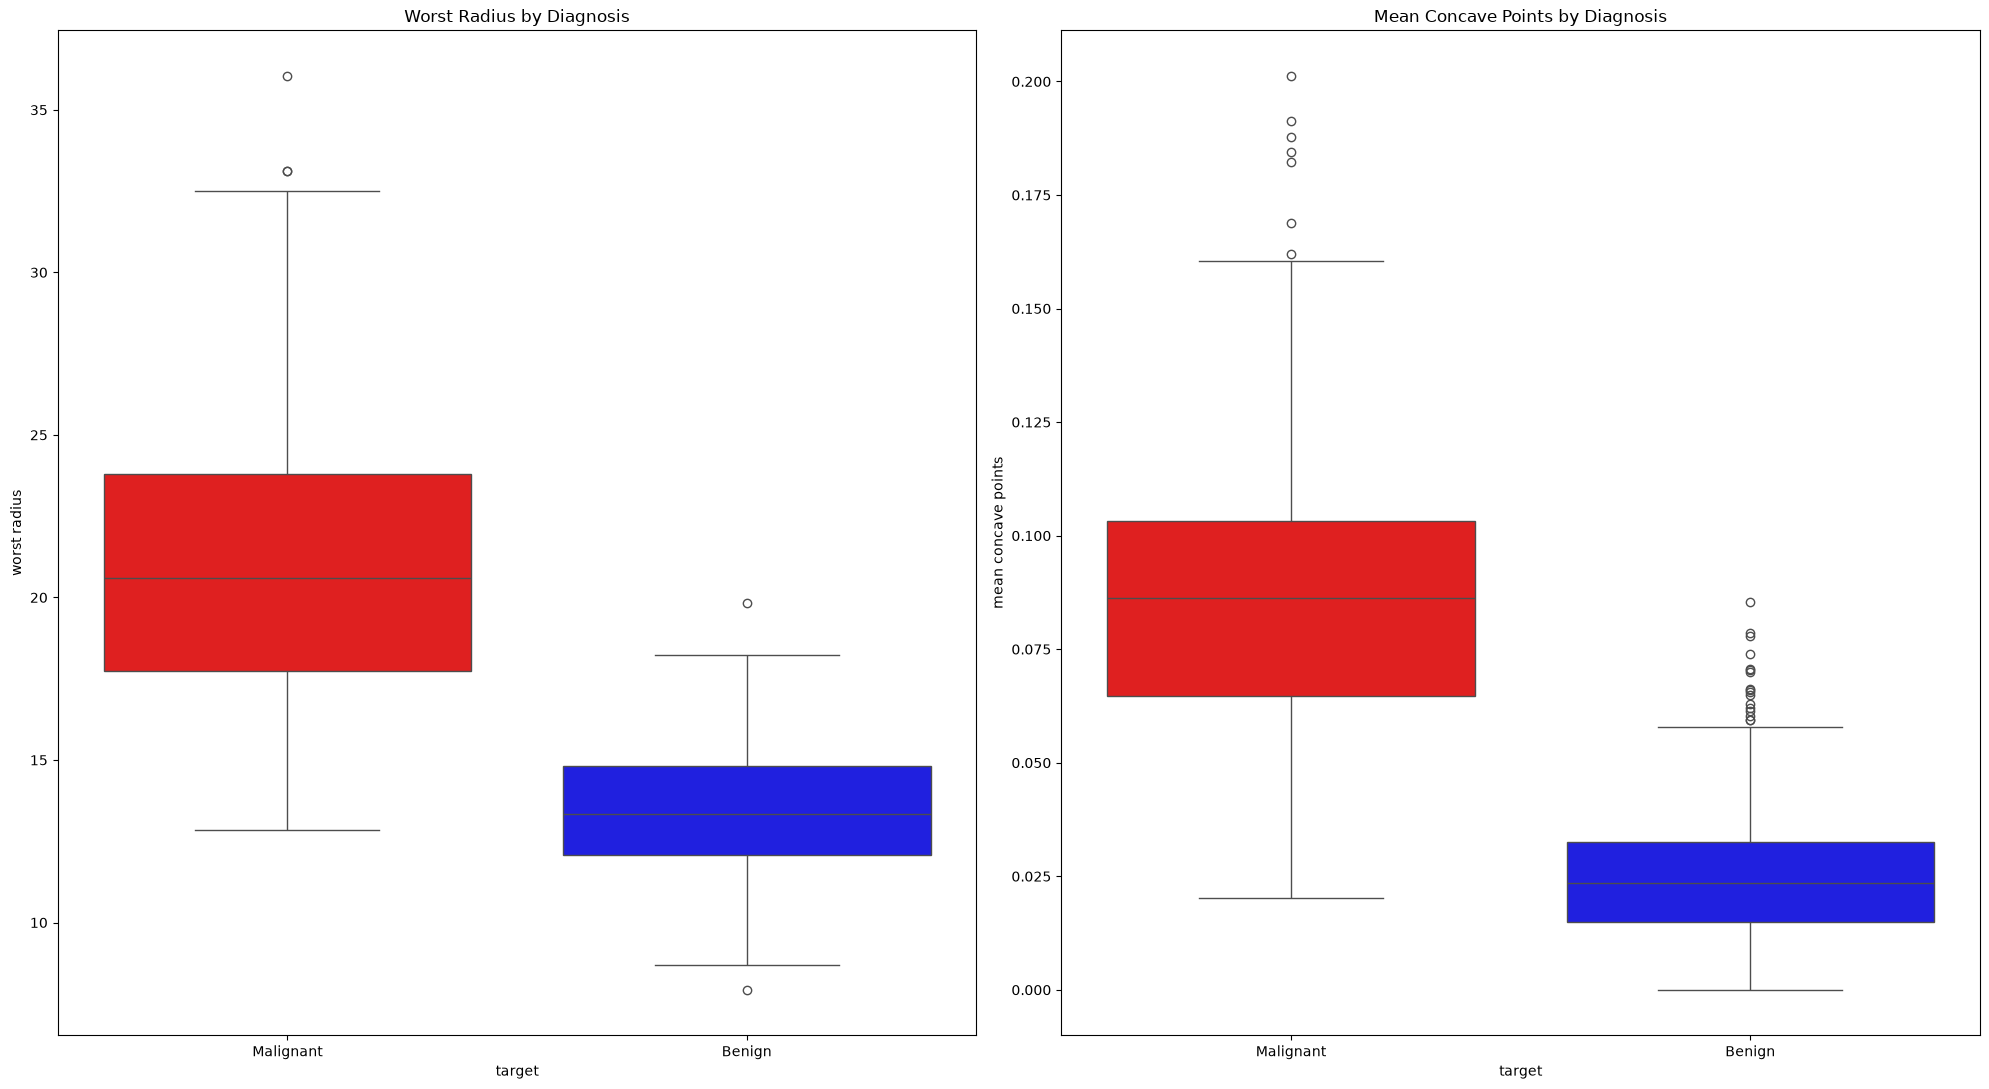

In [18]:
fig, axes = plt.subplots(1,2, figsize=(20,11))
sns.boxplot(x='target', y='worst radius', data= df, palette=['red', 'blue'], ax=axes[0])
axes[0].set_xticklabels(['Malignant', 'Benign'])
axes[0].set_title('Worst Radius by Diagnosis')

sns.boxplot(x='target', y='mean concave points', data= df, palette=['red', 'blue'], ax=axes[1])
axes[1].set_xticklabels(['Malignant', 'Benign'])
axes[1].set_title('Mean Concave Points by Diagnosis')

plt.tight_layout()
plt.show()


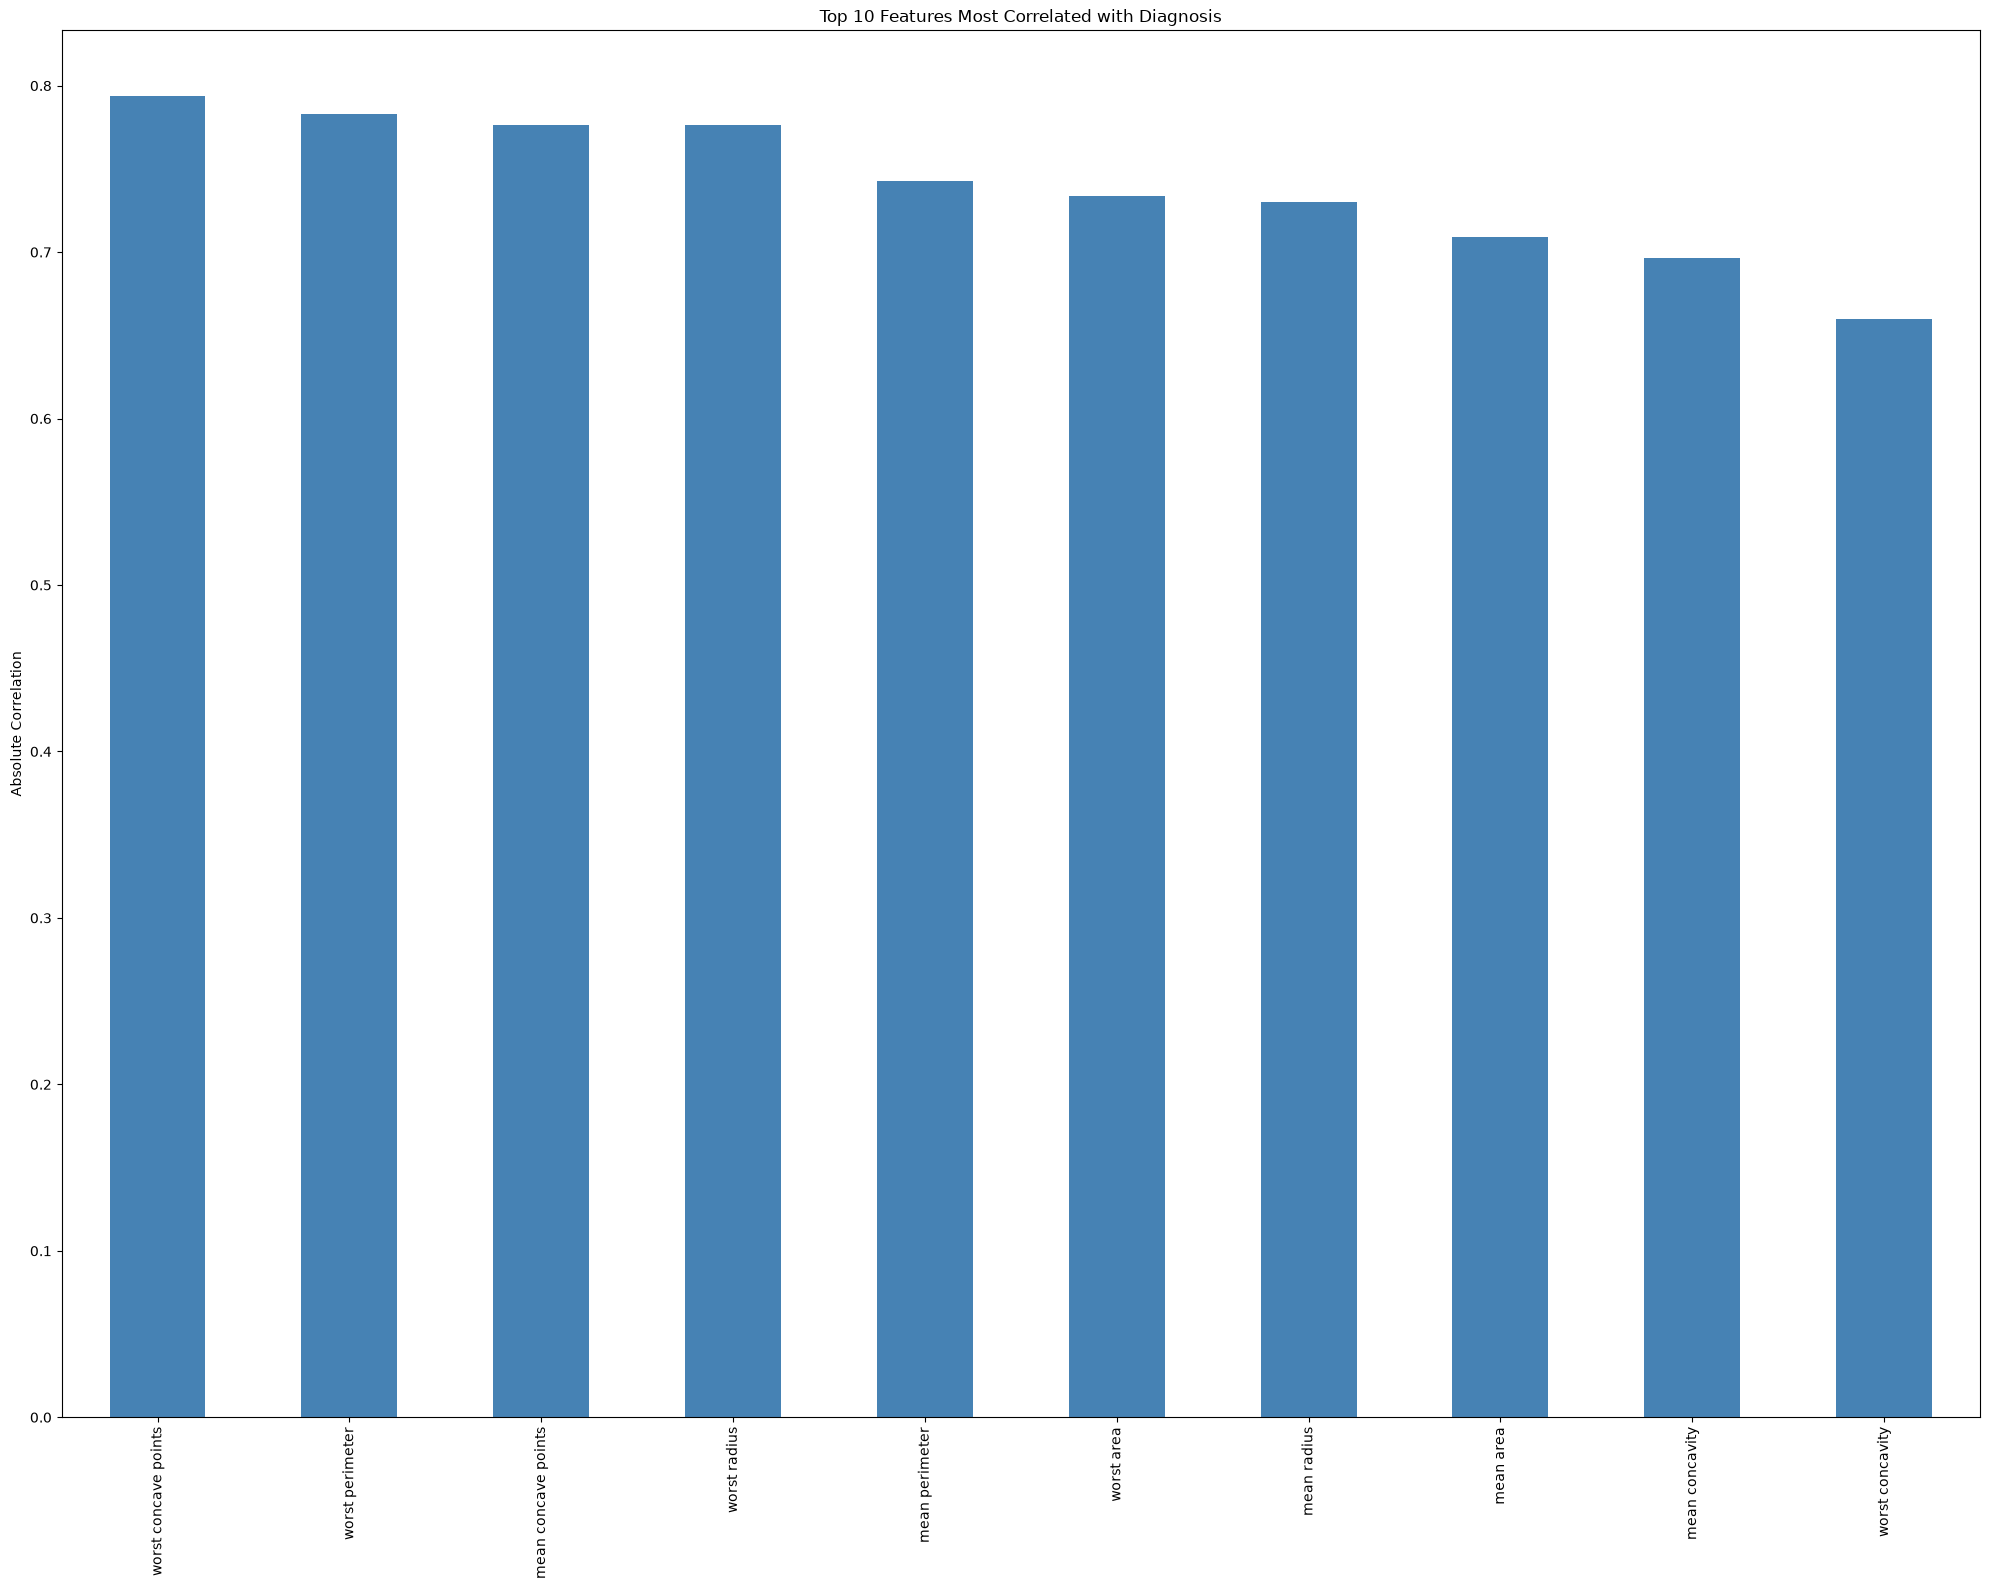

In [21]:
plt.figure(figsize=(20,16))
top_features = df.corr()['target'].drop('target').abs().sort_values(ascending=False).head(10)
top_features.plot(kind="bar", color ='steelblue')
plt.title('Top 10 Features Most Correlated with Diagnosis')
plt.ylabel('Absolute Correlation')
plt.tight_layout()
plt.show()